<a href="https://colab.research.google.com/github/deepkkumar07/Machine-Learning-Projects/blob/main/Decision_Tree_(Fruit_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
#importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [78]:
# imprting train test for splitting data
# sklearn.tree -- our decision tree classifeier is in sub folder of tree in sklear
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [79]:
#gettign data from sources
df = pd.read_csv('/content/drive/MyDrive/machine learning/Fruit Classification.csv')

In [80]:
#data
df

,Unnamed: 0,Color,Size,Fruit
0,0,Red,Large,Apple
1,1,Green,Large,Banana
2,2,Red,Medium,Banana
3,3,Red,Large,Apple
4,4,Red,Large,Apple
...,...,...,...,...
95,95,Green,Large,Apple
96,96,Green,Medium,Apple
97,97,Green,Large,Apple
98,98,Yellow,Small,Banana


In [81]:
df['Fruit'].value_counts()

,count
Fruit,
Apple,50
Banana,50


We use **Label Encoding** in **decision trees** primarily because decision trees are capable of handling ordered numeric values directly, and label encoding converts text categories into numbers seamlessly without expanding your data.

In [82]:
# label encoding
df['Color'] = df['Color'].map({'Green':0,'Yellow':1,'Red':2})
df['Fruit'] = df['Fruit'].map({'Apple':0, 'Banana':1})
df['Size'] = df['Size'].map({'Small':0,'Medium':1,'Large':2})


In [83]:
#data after label encoding
df

,Unnamed: 0,Color,Size,Fruit
0,0,2,2,0
1,1,0,2,1
2,2,2,1,1
3,3,2,2,0
4,4,2,2,0
...,...,...,...,...
95,95,0,2,0
96,96,0,1,0
97,97,0,2,0
98,98,1,0,1


In [84]:
#dropping unnamed: 0 column as this is a unique identifier and do not have a predictive power
df.drop('Unnamed: 0', axis=1 , inplace=True)

In [85]:
df

,Color,Size,Fruit
0,2,2,0
1,0,2,1
2,2,1,1
3,2,2,0
4,2,2,0
...,...,...,...
95,0,2,0
96,0,1,0
97,0,2,0
98,1,0,1


In [86]:
x= df[['Color','Size']] # is features
y= df[['Fruit']] # is output/dependent variable

In [87]:
# spliting data in 80 , 20 -- 80 for training , 20 for testing
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2,random_state = 42)

In [88]:
train_test_split(x,y, test_size= 0.2,random_state = 42) # to just check the trainig and testing data


[    Color  Size
 55      2     0
 88      2     0
 26      2     2
 42      0     0
 69      0     0
 ..    ...   ...
 60      0     2
 71      2     0
 14      1     1
 92      2     1
 51      0     1
 
 [80 rows x 2 columns],
     Color  Size
 83      2     0
 53      0     1
 70      0     2
 45      1     1
 44      1     0
 39      1     2
 22      1     0
 80      0     0
 10      2     2
 0       2     2
 18      1     2
 30      2     0
 73      1     1
 33      2     1
 90      2     2
 4       2     2
 76      1     1
 77      1     0
 12      2     0
 31      2     0,
     Fruit
 55      0
 88      1
 26      1
 42      0
 69      0
 ..    ...
 60      1
 71      0
 14      1
 92      1
 51      1
 
 [80 rows x 1 columns],
     Fruit
 83      0
 53      0
 70      0
 45      1
 44      0
 39      1
 22      0
 80      0
 10      1
 0       0
 18      0
 30      0
 73      0
 33      0
 90      0
 4       0
 76      0
 77      1
 12      0
 31      1]

In [ ]:
#model creation
model_logistic = LogisticRegression(max_iter=200)
#trainig mopdel
model_logistic.fit(x_train, y_train)

In [92]:
y_pred = model_logistic.predict(x_test) # passing the testing value to the model that we have trained

In [91]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[ 4 11]
 [ 1  4]]
0.4


#**Decision Tree**

In [95]:
#model creation and training
model_dt = DecisionTreeClassifier(criterion='entropy')
model_dt.fit(x_train, y_train)


DecisionTreeClassifier(criterion='entropy')

In [96]:
#prediction
test_pred = model_dt.predict(x_test)

In [98]:
#evaluating the model
print("accuracy of the model : ", accuracy_score(y_test, test_pred))


accuracy of the model :  0.55


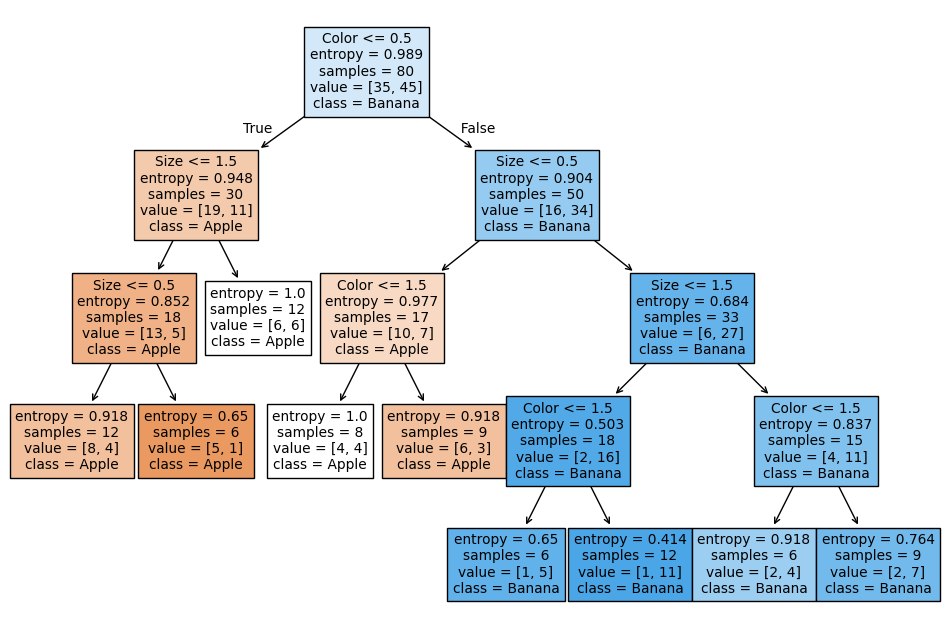

In [99]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

#ploting decsion tree
plt.figure(figsize=(12,8))
plot_tree(model_dt, filled=True , feature_names=['Color','Size'], class_names= ['Apple','Banana'])
plt.show()

In [ ]:
#df['Color'] = df['Color'].map({'Green':0,'Yellow':1,'Red':2})
#df['Fruit'] = df['Fruit'].map({'Apple':0, 'Banana':1})
#df['Size'] = df['Size'].map({'Small':0,'Medium':1,'Large':2})


In [100]:
#prdedictg the fruit
prediction = model_dt.predict([[2,0]]) # using unseen data
prediction = 'Apple' if prediction == 0 else 'Banana'
print(prediction)

Apple


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
